# Clustering - Lab 02

Having seen a bit of unsupervised learning through dimensionality reduction, it is important for us to get some practice in clustering techniques.
Clustering allows you to make sense of the data by identifying groups that could have been unnoticed before.
In this notebook, we will look at a problem related to clustering when identifying polymorphs of carbon from atomistic datasets

In [1]:
try:
    import google.colab
    IN_COLAB = True
    !git clone https://github.com/dskoda/ml4mat-26s-public.git
    !cd ml4mat-26s-public && pip install . && cd ..
    !pip install dscribe
    !pip install umap-learn
    !mkdir data
    !wget "https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/lectures/04-Unsupervised/data/GAP20-reduced.xyz" -O "data/GAP20-reduced"
    ROOT = "."
    STYLE = "colab"
except:
    IN_COLAB = False
    ROOT = "."
    STYLE = "jupyter"

In [2]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

# ase is the package we use to read files related to atomistic structures
from ase import Atoms
from ase.io import read

# we will import the dimensionality reduction and clustering algorithms as well
from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.cluster import KMeans

# dscribe is one package that is widely used for featurization of atomistic structures
from dscribe.descriptors import SOAP

import ml4mat_ucla as m4m

plt.style.use(STYLE)
m4m.utils.set_dpi(200)

## Loading and featurizing the dataset

### Loading the data

The first thing we need to do is to load and featurize the dataset.
Here, we are using a small subset of the GAP-20 carbon dataset from [Rowe et al. (2020)](https://doi.org/10.1063/5.0005084), which contains data of energy and forces for several polymorphs of carbon.

In [3]:
dset = read(f"{ROOT}/data/GAP20-reduced.xyz", index=":")

n_structs = len(dset)
n_atoms = sum([len(struct) for struct in dset])

print(n_structs, n_atoms)

140 12030


Here, we see that the dataset contains 140 structures, which sum up to 12k atoms.
The instructor added a few extra pieces of information in this dataset to make it easier to follow in this lecture, specifically, the ground-truth label of the polymorph corresponding to each structure.

In [4]:
# retrieve info
LABELS = set([struct.info["Polymorph"] for struct in dset])

# create a dictionary with the labels
LABELS = {label: i for i, label in enumerate(sorted(LABELS))}

print(LABELS.keys())

dict_keys(['Amorphous_Bulk', 'Diamond', 'Fullerenes', 'Graphene', 'Graphite', 'Liquid', 'Nanotubes'])


The labels above give us a pretty good idea of what are the phases of carbon that we can expect to see in our analysis.

### Featurizing

Now that we loaded the dataset, we have to create a representation for the structures.
In particular, we will use the SOAP representation that we discussed in the lecture to represent each carbon atom in each polymorph.
Importantly, remember that, in this case, the representation is made for **each atom**, not each structure.
This is important, as there are other ways we can represent entire structures with other operations - for example, taking the mean of all representations of atoms.

Let's use the `dscribe` package to create a SOAP representation for the carbon polymorphs. The hyperparameters are determined by the basis set ($n = 6, \ell = 5$) and radial cutoff ($r_c = 5$ Å), and structures are considered as periodic.

In [5]:
species = ["C"]
r_cut = 5.0
n_max = 6
l_max = 5

soap = SOAP(
    species=species,
    periodic=True,
    r_cut=r_cut,
    n_max=n_max,
    l_max=l_max,
)

Now, we can create the SOAP representation for each atom on a per-structure basis of the dataset:

In [6]:
# creating the representation matrix by concatenating all structures
X = np.concatenate([
    soap.create(struct) for struct in dset
])

# creating the labels based on the names of each structure.
# the labels are defined in a per-atom basis.
y = np.concatenate([
    [LABELS[struct.info["Polymorph"]] for _ in range(len(struct))]
    for struct in dset
])

# creating another set of "features" just to illustrate
# in this case, we choose the density in atoms/Å^3
densities = np.concatenate([
    [len(struct) / struct.get_volume() for _ in range(len(struct))]
    for struct in dset
])

 Let's investigate the shape of each one of these matrices:

In [7]:
print(X.shape, y.shape)

(12030, 126) (12030,)


You can see that, in this case, each one of the 12,030 atoms in the dataset has a feature vector of dimension 126. 
Let's see what is the distribution of densities in our systems:

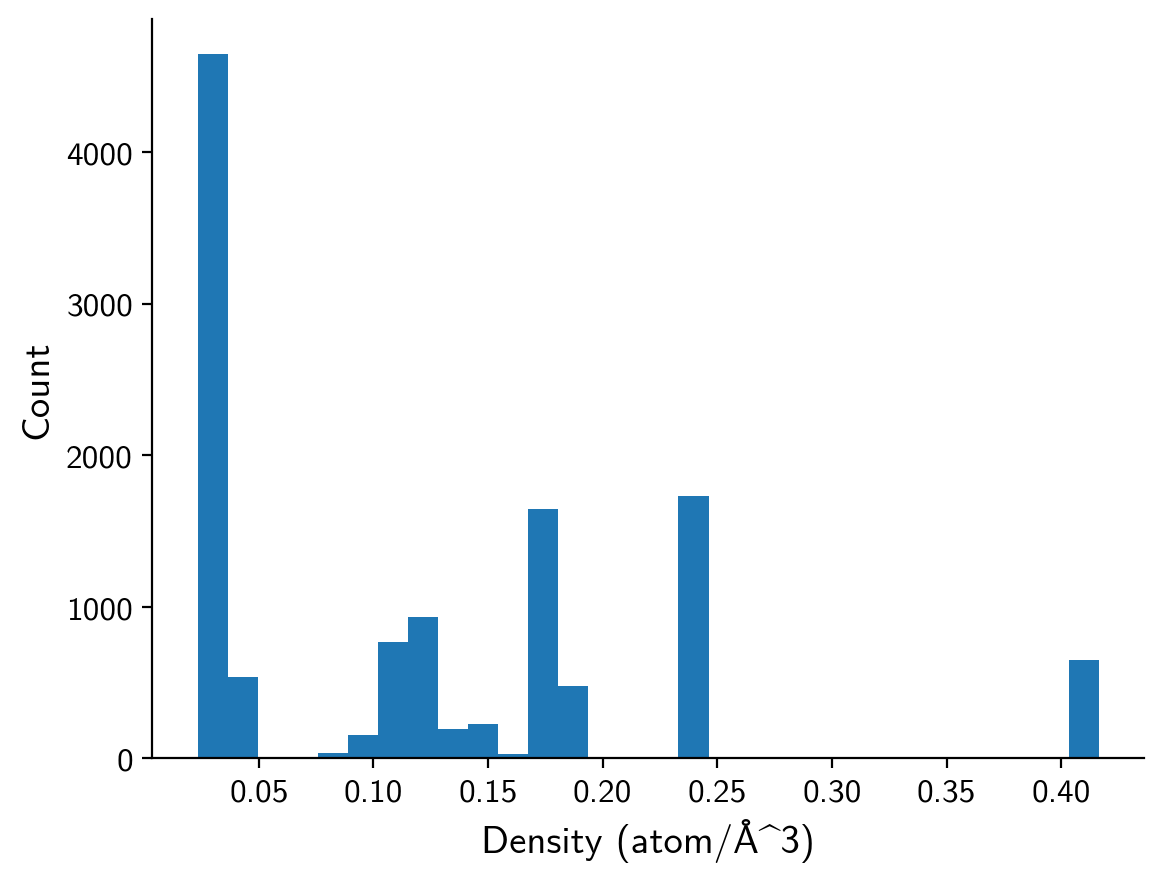

In [8]:
fig, ax = plt.subplots()

ax.hist(densities, bins=30)

ax.set_xlabel("Density (atom/Å^3)")
ax.set_ylabel("Count")

plt.show()

Let's look at one of these vectors just to see how it looks like:

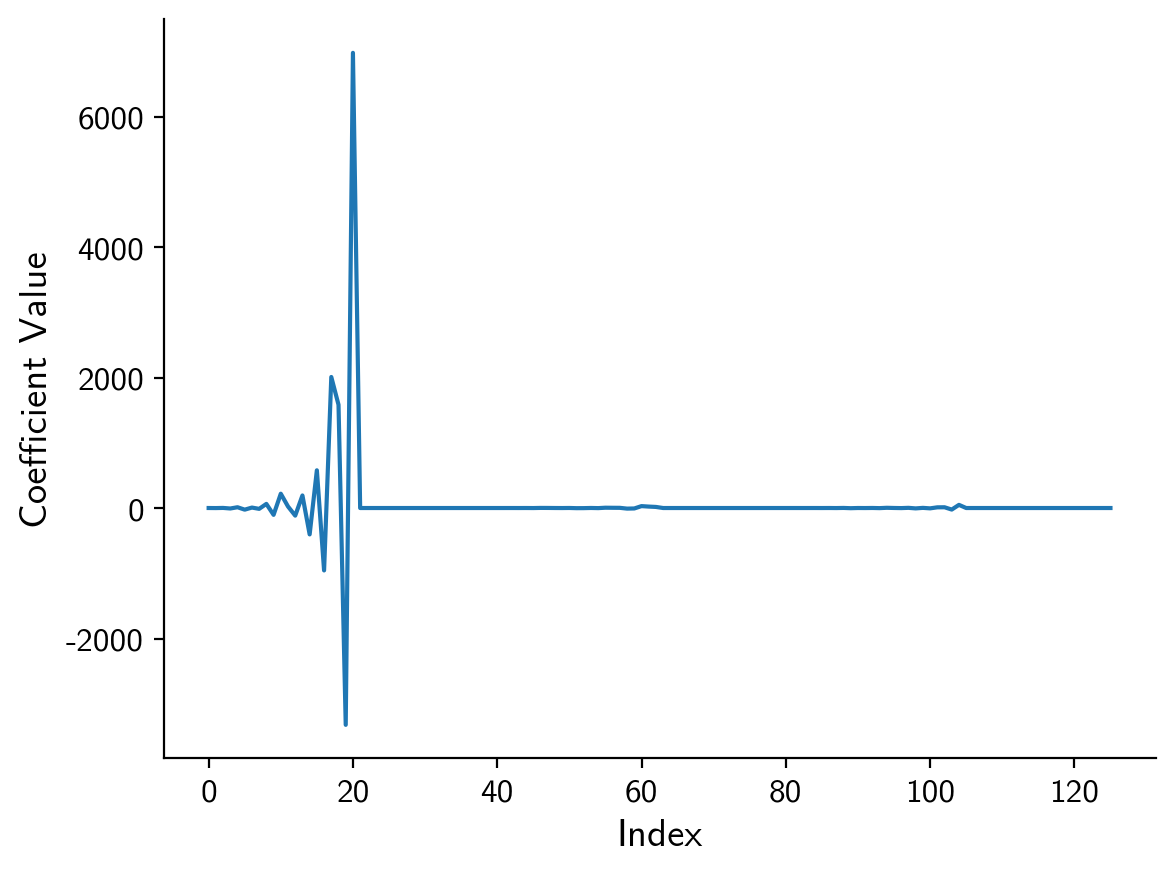

In [9]:
fig, ax = plt.subplots()

ax.plot(X[0])

ax.set_xlabel("Index")
ax.set_ylabel("Coefficient Value")

plt.show()

## Exercise 1: dimensionality reduction

You have seen how to do dimensionality reduction in the previous notebook. Using the labels `y` we created (whose names are available in the dictionary `LABELS`), perform some dimensionality reduction on the dataset of carbon polymorphs. Use the code from the previous notebook as appropriate.

Can you see what happens with the dimensionality reduction methods? What insights can you extract from this?

## Exercise 2: clustering

Now that you have analyzed the plots for the dimensionality reduction, try clustering the data and using the predicted clusters as colors in your reduced-dimensionality plot. Use k-means clustering for this initial task, and the code below as guideline. In particular, try performing clustering over different features (reduced or not) to see what happens.

In [10]:
N_CLUSTERS = 1234  # MAKE SURE YOU GUESS AN APPROPRIATE NUMBER OF CLUSTERS HERE!

kmeans = KMeans(n_clusters=N_CLUSTERS)

# clusters = kmeans.fit_predict(MATRIX)  # which MATRIX is the one you are going to use here?

## Exercise 3: determining the number of clusters

Now that you know how to perform clustering, you could ask: how do I determine the ideal number of clusters?

Try performing the clustering above for several different number of clusters. 
You can try to verify how to get the loss of the algorithm (i.e., how well it performs) by using the code below.
Usually, lower loss is better, but less clusters is also better.

How are you going to decide on the number of clusters?

In [11]:
# kmeans = KMeans(n_clusters=n) # do this for multiple values of `n`
# kmeans.fit(MATRIX)
# loss = -kmeans.score(MATRIX)